In [1]:
import os
import random
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [4]:
# ===== CONFIG =====
raw_data_dir = "c:/Users/user/Documents/Real_time_weapon_detection/datasets"  # <-- your raw dataset folder
openmv_size = (96, 96)  # Native OpenMV resolution
model_input_size = (224, 224)  # Model input size
label_map = {
    "human_with_weapon": "THREAT",
    "weapon_only": "THREAT",
    "human_only": "NO_THREAT",
    "no_threat": "NO_THREAT"
}

# Load trained model
model = tf.keras.models.load_model("mobilenetv2_best_model.h5")

# ===== FUNCTION: Simulate OpenMV camera effects =====
def simulate_camera_effects(img):
    # Random brightness
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.7, 1.3))
    # Random contrast
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))
    # Random blur
    if random.random() < 0.3:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0, 1.5)))
    return img

# ===== LOAD RAW IMAGES =====
images = []
labels = []

for class_name in os.listdir(raw_data_dir):
    class_path = os.path.join(raw_data_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    
    mapped_label = label_map[class_name]
    
    for fname in os.listdir(class_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            fpath = os.path.join(class_path, fname)
            try:
                # Load as RGB (OpenMV outputs RGB565)
                img = Image.open(fpath).convert("RGB")
                # Resize to OpenMV native size
                img = img.resize(openmv_size)
                # Apply random camera artifacts
                img = simulate_camera_effects(img)
                # Upscale to model input size
                img = img.resize(model_input_size)
                # Normalize
                img_array = np.array(img, dtype=np.float32) / 255.0
                images.append(img_array)
                labels.append(mapped_label)
            except Exception as e:
                print(f"Could not load {fpath}: {e}")

images = np.array(images)
labels = np.array(labels)

# Encode labels
label_names = np.unique(labels)
label_to_index = {name: i for i, name in enumerate(label_names)}
y_true = np.array([label_to_index[l] for l in labels])

# ===== RUN INFERENCE =====
y_pred_probs = model.predict(images, batch_size=32)
y_pred = np.argmax(y_pred_probs, axis=1)



38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step


Classification Report:
              precision    recall  f1-score   support

   NO_THREAT       0.85      0.95      0.90       493
      THREAT       0.96      0.88      0.92       698

    accuracy                           0.91      1191
   macro avg       0.91      0.92      0.91      1191
weighted avg       0.92      0.91      0.91      1191

Confusion Matrix:


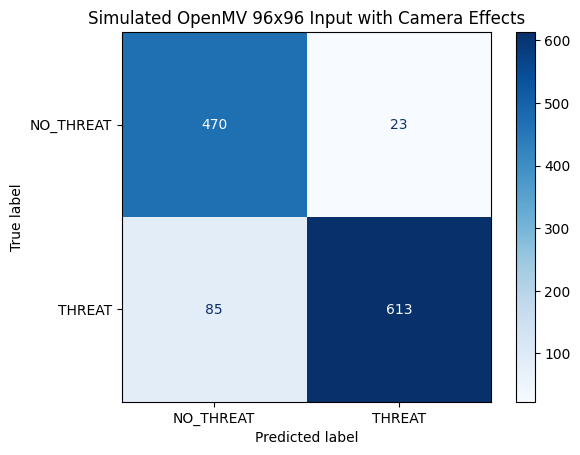

In [5]:
# ===== EVALUATION =====
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=label_names))

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Simulated OpenMV 96x96 Input with Camera Effects")
plt.show()

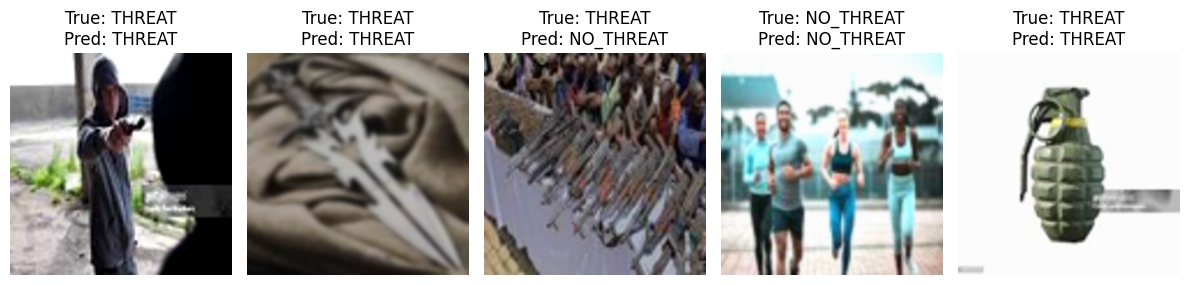

In [6]:
# ===== SHOW RANDOM RESULTS =====
plt.figure(figsize=(12, 6))
for i in range(5):
    idx = random.randint(0, len(images)-1)
    plt.subplot(1, 5, i+1)
    plt.imshow(images[idx])
    plt.title(f"True: {labels[idx]}\nPred: {label_names[y_pred[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()